# Greenland Ice Velocity fetching and handling using OpenDAP tutorial
The PROMICE Ice Velocity product is a time-series of Greenland Ice Sheet velocity mosaics based on ESA Sentinel-1 SAR offset tracking (spatial resolution: 200 m). A new mosaic spanning 2 Sentinel-1A/-1B/-1C cycles is posted every 12 days, with each new mosaic supplied as a NetCDF file. The data product is described in detail in [Solgaard et al. (2021)](https://doi.org/10.5194/essd-13-3491-2021)
We aim to make each new mosaic available within 10 days of the last included acquisition.

Here, we will look at how to query and fetch the dataset from our [Thredds server](https://thredds.geus.dk/), which is where we store and operationally update the PROMICE Ice Velocity product. Specifically, we will look at:
1. Connecting to the PROMICE Ice Velocity dataset using OpenDAP
2. Querying and fetching data from a given point
2. Querying and fetching data from a given region

For more information on how to handle a single file in the dataset, please refer to the previous introductory tutorial.

So first, let's import all the packages we will be using.

In [27]:
# For dataset loading and handling
import xarray as xr
import numpy as np

# For plotting
import matplotlib.pyplot as plt

## 1. Connecting to the PROMICE Ice Velocity dataset using OpenDAP
The PROMICE Ice Velocity product is available on the [GEUS Thredds server](https://thredds.geus.dk/). First let's connect to the dataset using OpenDAP querying. With this, we can load the data structure but not actually downloaded anything. This is one of the strengths of OpenDAP querying - we can inspect the data without actually beginning the heavy operation of downloading.

In [2]:
url = "https://thredds.geus.dk/thredds/dodsC/IVData/IV_ROTR_Agg.nc"
ds = xr.open_dataset(url)

ds

<xarray.Dataset> Size: 43GB
Dimensions:                                  (time: 15, bnds: 2, y: 13500,
                                              x: 7500)
Coordinates:
  * time                                     (time) datetime64[ns] 120B 2025-...
  * y                                        (y) float64 108kB -6.5e+05 ... -...
  * x                                        (x) float64 60kB -6.5e+05 ... 8....
Dimensions without coordinates: bnds
Data variables:
    crs                                      |S64 64B ...
    time_bnds                                (time, bnds) datetime64[ns] 240B ...
    land_ice_surface_easting_velocity        (time, y, x) float32 6GB ...
    land_ice_surface_northing_velocity       (time, y, x) float32 6GB ...
    land_ice_surface_vertical_velocity       (time, y, x) float32 6GB ...
    land_ice_surface_velocity_magnitude      (time, y, x) float32 6GB ...
    land_ice_surface_easting_velocity_std    (time, y, x) float32 6GB ...
    land_ice_surface_northing_velocity_std   (time, y, x) float32 6GB ...
    land_ice_surface_velocity_magnitude_std  (time, y, x) float32 6GB ...
Attributes:
    Conventions:          CF-1.5
    time_coverage_start:  2025-12-06
    time_coverage_end:    2025-12-30
    sensors_used:         Sentinel-1A,Sentinel-1C
    institution:          GEUS
    methods_used:         Offset-tracking
    calibration_method:   None
    title:                Greenland Ice Velocity from 2025-12-06 to 2025-12-30
    summary:              Greenland Ice Velocity from Sentinel-1 offset track...
    product_version:      1.0
    DODS.strlen:          0

Let's inspect the data then. You can see we have three dimensions (listed as coordinates)- a time dimension called `time`, and two spatical dimensions called `x` and `y` which represent latitute and longitude.

We also have a number of variables. Let's look at these a little closer to get some more information about them.

In [4]:
ds.variables

Frozen({'crs': <xarray.Variable ()> Size: 64B
[1 values with dtype=|S64]
Attributes:
    grid_mapping_name:                      polar_stereographic
    standard_parallel:                      70.0
    longitude_of_prime_meridian:            0.0
    straight_vertical_longitude_from_pole:  -45.0
    semi_major_axis:                        6378137.0
    inverse_flattening:                     298.257223563
    latitude_of_projection_origin:          90.0
    false_easting:                          0.0
    false_northing:                         0.0, 'time_bnds': <xarray.Variable (time: 15, bnds: 2)> Size: 240B
[30 values with dtype=datetime64[ns]]
Attributes:
    _ChunkSizes:  [1 2], 'land_ice_surface_easting_velocity': <xarray.Variable (time: 15, y: 13500, x: 7500)> Size: 6GB
[1518750000 values with dtype=float32]
Attributes:
    units:          m/day
    description:    easting ice velocity
    grid_mapping:   crs
    cell_methods:   time: mean (weighted average (based on error estimat

Here, we have listed all of the metadata associated with the data variables, including a long name, description and spatial projection. We have directional ice velocity variables (`land_ice_surface_easting_velocity` and `land_ice_surface_northing_velocity`) and the horizontal ice velocity magnitude (`land_ice_surface_velocity_magnitude`), along with vertical ice velocity magnitude (`land_ice_surface_vertical_velocity`), and the errors associated with these velocities (ending with `_std`).

Next, let's look at the spatial coordinates, which will be useful when we come to the next step for extracting data from a specified point, or region.

In [12]:
x_min = ds["x"].min().values
x_max = ds["x"].max().values

y_min = ds["y"].min().values
y_max = ds["y"].max().values

print(x_min)
print(x_max)
print(y_min)
print(y_max)

-650000.0
849800.0
-3349800.0
-650000.0


These coordinates and the range we can query from to download data for a specific point or region. Let's move on to downloading data for a given point.

## 2. Querying and fetching data from a given point
We will now define a point location and download data from the nearest grid point. We'll start with a point on Helheim Glacier, a fast-flowing tidewater glacier in Southeast Greenland.

In [13]:
# Define point at Helheim Glacier
x = 302500      # lat metres (EPSG:3413)
y = -2578000    # lon metres (EPSG:3413)

# Extract nearest grid point
pt = ds.sel(
    x = x,
    y = y,
    method="nearest"
)

pt

<xarray.Dataset> Size: 860B
Dimensions:                                  (time: 15, bnds: 2)
Coordinates:
  * time                                     (time) datetime64[ns] 120B 2025-...
    y                                        float64 8B -2.578e+06
    x                                        float64 8B 3.026e+05
Dimensions without coordinates: bnds
Data variables:
    crs                                      |S64 64B ...
    time_bnds                                (time, bnds) datetime64[ns] 240B ...
    land_ice_surface_easting_velocity        (time) float32 60B ...
    land_ice_surface_northing_velocity       (time) float32 60B ...
    land_ice_surface_vertical_velocity       (time) float32 60B ...
    land_ice_surface_velocity_magnitude      (time) float32 60B ...
    land_ice_surface_easting_velocity_std    (time) float32 60B ...
    land_ice_surface_northing_velocity_std   (time) float32 60B ...
    land_ice_surface_velocity_magnitude_std  (time) float32 60B ...
Attributes:
    Conventions:          CF-1.5
    time_coverage_start:  2025-12-06
    time_coverage_end:    2025-12-30
    sensors_used:         Sentinel-1A,Sentinel-1C
    institution:          GEUS
    methods_used:         Offset-tracking
    calibration_method:   None
    title:                Greenland Ice Velocity from 2025-12-06 to 2025-12-30
    summary:              Greenland Ice Velocity from Sentinel-1 offset track...
    product_version:      1.0
    DODS.strlen:          0

This returns all variables at the nearest grid cell. If we only need one specific variable, we can first select the variable and then download the data for that variable.

In [15]:
# Select velocity magnitude variable
variable = ds["land_ice_surface_velocity_magnitude"]

# Extract nearest grid point
pt_var = variable.sel(
    x = x,
    y = y,
    method="nearest"
)

# Return all horizontal velocity magnitudes from this point
pt_var.values

array([20.7228  , 20.845234, 20.905582, 21.368929, 21.502224, 21.770544,
       22.110342, 21.754316, 21.866257, 21.660791, 21.760893, 21.557226,
       21.384962, 21.169113, 20.803095], dtype=float32)

We can visualise this point by overlaying it onto an ice velocity map of the surrounding region, like so.

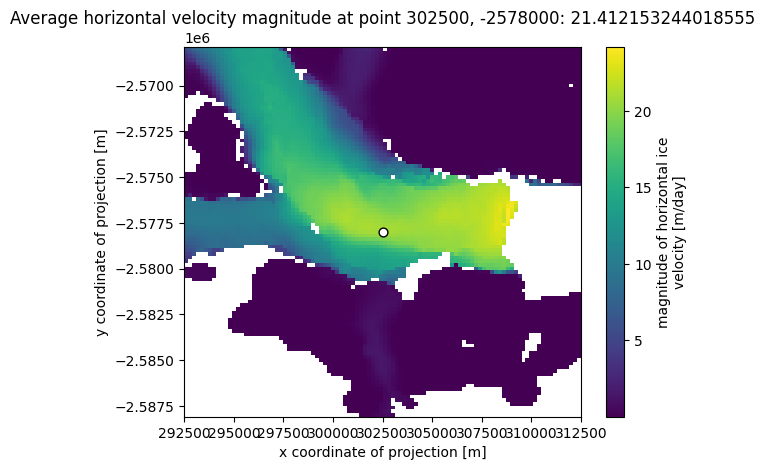

In [29]:
# Prime plotting space
plt.figure()

# Plot velocity magnitude
vel = variable.sel(
    x=slice(x-10000, x+10000),     # lat metres (EPSG:3413)
    y=slice(y+10000, y-10000)    # lon metres (EPSG:3413)
)
vel.isel(time=0).plot()

# Plot point
plt.scatter(x, y, c="white", s=40, marker="o", edgecolors="black")

# Calculate average velocity at point
mean = np.mean(pt["land_ice_surface_velocity_magnitude"].values)

# Construct title including velocity magnitude value
plt.title(f"Average horizontal velocity magnitude at point {x}, {y}: {mean}")

# Show plot
plt.show()

We can also plot ice velocity at this point in a time-series.

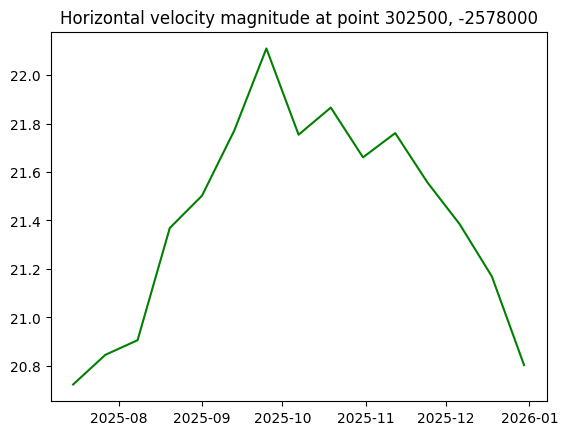

In [31]:
# Download data at given point
pt = ds.sel(
    x=x,     # lat metres (EPSG:3413)
    y=y,    # lon metres (EPSG:3413)
    method="nearest"
)

# Prime plotting space
plt.figure()

# Plot velocities over time with error bars
plt.plot(pt["time"], pt["land_ice_surface_velocity_magnitude"], color="green")
plt.title(f"Horizontal velocity magnitude at point {x}, {y}")

# Show plot
plt.show()

## 3. Querying and fetching data from a given region
Let's now define a region and download data for a given region. We'll take a region within the Hagen Bræ catchment, which is a tidewater glacier in Northeast Greenland. We'll first download the data for this region.

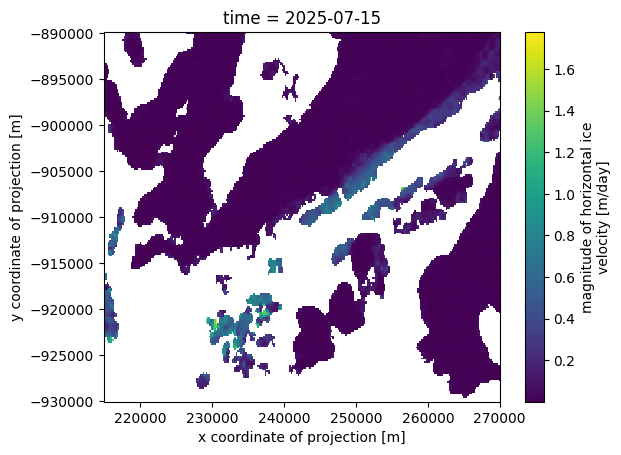

In [34]:
# Define region
x1=215000
x2=270000
y1=-890000
y2=-930000

# Download all variables within this region
region = ds.sel(
    x=slice(x1, x2),
    y=slice(y1, y2)
)

# Plot horizontal velocity magnitude at Hagen Brae for first time step
vel = region["land_ice_surface_velocity_magnitude"]
plt.figure()
vel.isel(time=0).plot()

If we want to produce the average ice velocity over a region then we can calculate the mean of all ice velocity values over the time dimension.

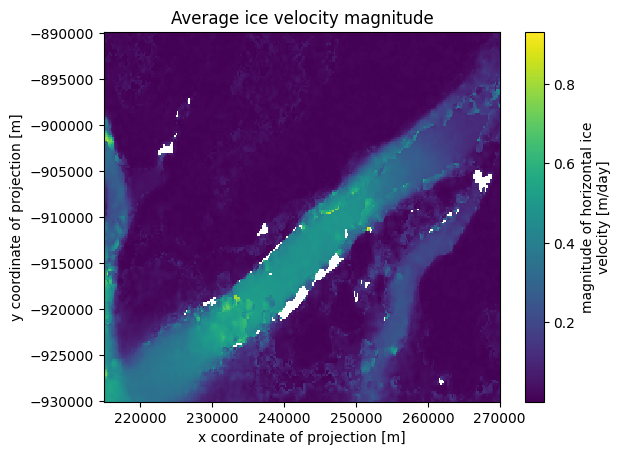

In [40]:
region_vel = region["land_ice_surface_velocity_magnitude"]
region_average = region_vel.mean(dim="time")

# Plot average horizontal velocity magnitude at Hagen Brae
plt.figure()
region_average.plot()
plt.title("Average ice velocity magnitude")
plt.show()

Also, if we want to limit our query to a specific time period then we can also provide a time slice.

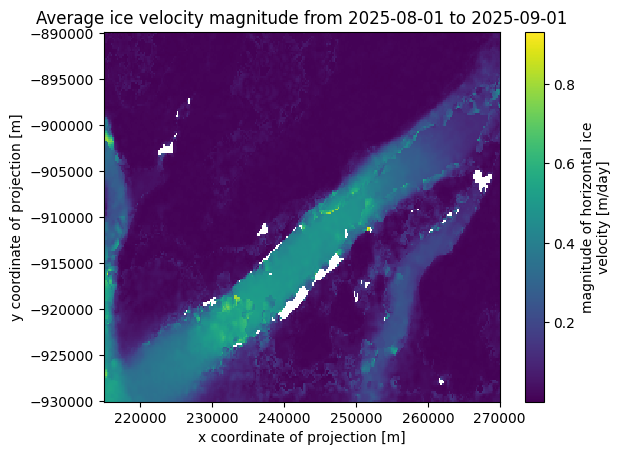

In [42]:
# Define time period
start = "2025-08-01"
end =  "2025-09-01"

# Download all variables within this region
region_with_time = ds.sel(
            x=slice(x1, x2),
            y=slice(y1, y2),
            time=slice(start, end)
)

# Extract horizontal velocity magnitude
vel_with_time = region_with_time["land_ice_surface_velocity_magnitude"]

# Calculate mean for all values across the defined time period
vel_average = vel_with_time.mean(dim="time")

# Plot horizontal velocity magnitude at Hagen Brae for first time step

plt.figure()
vel_average.isel().plot()
plt.title(f"Average ice velocity magnitude from {start} to {end}")
plt.show()

Now let's generate a time-series of velocities across a flowline.

This flowline should be a one-dimensional line that represents a glacier's primary path of ice flow. We will firstly make a hypothetical flowline ourselves over the catchment of Hagen Bræ in Northeast Greenland. Then we will generate a velocity time-series over this flowline, capturing the average, minimum and maximum velocity.

Firstly, let's define our flowline as a set of predefined points. Then we will generate evenly spaced points along our flowline, and compute the cumulative distance along this. We'll plot it onto the first velocity field in our dataset, to see how it looks.

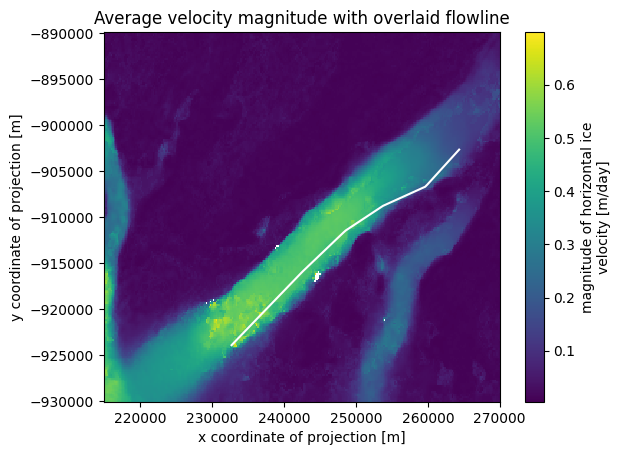

In [50]:
# Define flowline point locations
flowline_x = np.array([264352, 259672, 253754, 248511, 242556, 237624, 232692])
flowline_y = np.array([-902677, -906701, -908797, -911508, -915952, -919951, -923950])

dist_flowline = np.zeros(len(flowline_x))
for i in range(1, len(flowline_x)):
    dx = flowline_x[i] - flowline_x[i-1]
    dy = flowline_y[i] - flowline_y[i-1]
    dist_flowline[i] = dist_flowline[i-1] + np.sqrt(dx**2 + dy**2)

# Number of points along flowline
n_points = 100
even_dist = np.linspace(0, dist_flowline[-1], n_points)

# Interpolate x, y at evenly spaced distances
x_even = np.interp(even_dist, dist_flowline, flowline_x)
y_even = np.interp(even_dist, dist_flowline, flowline_y)

# Plot horizontal velocity magnitude at Hagen Brae
region = ds.sel(
    x=slice(x1, x2),
    y=slice(y1, y2)
)
vel_mean = region["land_ice_surface_velocity_magnitude"].mean(dim="time")
plt.figure()
vel_mean.plot()
plt.title("Average velocity magnitude with overlaid flowline")

# Overlay flowline point locations
plt.plot(x_even, y_even, c="white")

# Show plot
plt.show()

We can now extract velocity values at the nearest grid points of the dataset using a nearest neighbour interpolation, carried out by the Dataset object.

In [55]:
vel = region["land_ice_surface_velocity_magnitude"]
flowline_vel = vel.interp(
    x=("points", x_even),
    y=("points", y_even),
    method="nearest"
)
flowline_vel.shape

(15, 100)

In [58]:
flowline_mean = flowline_vel.mean(dim="points")
flowline_max = flowline_vel.max(dim="points")
flowline_min = flowline_vel.min(dim="points")

print(flowline_mean.values)
print(flowline_max.values)
print(flowline_min.values)

[0.49776408 0.42833963 0.36618254 0.3754523  0.38018063 0.38597816
 0.40038317 0.40975887 0.3977389  0.40469456 0.41462764 0.4106858
 0.4075379  0.41486812 0.42099896]
[1.3347231  1.0176269  0.7555186  0.62640005 0.5504686  0.5205112
 0.5368629  0.5796053  0.52922446 0.5304596  0.54136616 0.541916
 0.54314244 0.54361296 0.7286709 ]
[0.1643554  0.14765874 0.17009622 0.11593692 0.13336731 0.10192327
 0.03391799 0.14631326 0.13282306 0.13214304 0.10093421 0.12321874
 0.14981325 0.1223234  0.11221702]


And then we can plot our velocity profile along the flowline, specifically plotting time versus flowline velocity (average, maximum and minimum).

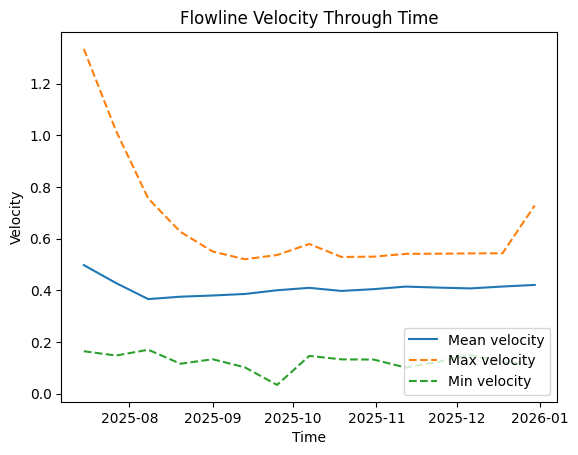

In [54]:
plt.figure()

plt.plot(flowline_vel.time, flowline_mean, label="Mean velocity")
plt.plot(flowline_vel.time, flowline_max, "--", label="Max velocity")
plt.plot(flowline_vel.time, flowline_min, "--", label="Min velocity")

plt.legend(loc="lower right")
plt.title("Flowline Velocity Through Time")
plt.xlabel("Time")
plt.ylabel("Velocity")

plt.show()